# Proyecto Modelos y Simulación de Sistemas I

In [1]:
import polars as pl
import opendatasets as od


In [2]:
link = "https://www.kaggle.com/competitions/udea-ai-4-eng-20251-pruebas-saber-pro-colombia"
od.download(link)

Skipping, found downloaded files in "./udea-ai-4-eng-20251-pruebas-saber-pro-colombia" (use force=True to force download)


In [3]:
csv_file = "udea-ai-4-eng-20251-pruebas-saber-pro-colombia/train.csv"
csv_file_test = "udea-ai-4-eng-20251-pruebas-saber-pro-colombia/test.csv"

### Cargar el csv

In [4]:
train_df = pl.scan_csv(csv_file)
test_df = pl.scan_csv(csv_file_test)

In [5]:
first_two_rows = train_df.head(2).collect()

display(first_two_rows)

ID,PERIODO,ESTU_PRGM_ACADEMICO,ESTU_PRGM_DEPARTAMENTO,ESTU_VALORMATRICULAUNIVERSIDAD,ESTU_HORASSEMANATRABAJA,FAMI_ESTRATOVIVIENDA,FAMI_TIENEINTERNET,FAMI_EDUCACIONPADRE,FAMI_TIENELAVADORA,FAMI_TIENEAUTOMOVIL,ESTU_PRIVADO_LIBERTAD,ESTU_PAGOMATRICULAPROPIO,FAMI_TIENECOMPUTADOR,FAMI_TIENEINTERNET.1,FAMI_EDUCACIONMADRE,RENDIMIENTO_GLOBAL,coef_1,coef_2,coef_3,coef_4
i64,i64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,f64,f64,f64,f64
904256,20212,"""ENFERMERIA""","""BOGOTÁ""","""Entre 5.5 millones y menos de …","""Menos de 10 horas""","""Estrato 3""","""Si""","""Técnica o tecnológica incomple…","""Si""","""Si""","""N""","""No""","""Si""","""Si""","""Postgrado""","""medio-alto""",0.322,0.208,0.31,0.267
645256,20212,"""DERECHO""","""ATLANTICO""","""Entre 2.5 millones y menos de …","""0""","""Estrato 3""","""No""","""Técnica o tecnológica completa""","""Si""","""No""","""N""","""No""","""Si""","""No""","""Técnica o tecnológica incomple…","""bajo""",0.311,0.215,0.292,0.264


| Columna                      | Tipo de Variable      | Acción de Codificación                                                                                                                                   |
|------------------------------|-----------------------|----------------------------------------------------------------------------------------------------------------------------------------------------------|
| `RENDIMIENTO_GLOBAL`         | Ordinal (Target)      | Mapear a valores numéricos `0`–`3` según el orden (e.g., `"bajo": 0`, `"medio-bajo": 1`, `"medio-alto": 2`, `"alto": 3`)                                  |
| `FAMI_ESTRATOVIVIENDA`       | Ordinal               | Mapear `"Estrato 1"`…`"Estrato 6"` a valores numéricos `1`…`6`                                                                                           |
| `ESTU_HORASSEMANATRABAJA`    | Ordinal               | Mapear rangos de texto (e.g., `"0"`, `"Menos de 10 horas"`, etc.) a valores numéricos ordinales                                                          |
| `FAMI_TIENEINTERNET`         | Categórica Binaria    | Convertir a `0` (No) / `1` (Si) y castear a `UInt8`                                                                                                      |
| `FAMI_TIENELAVADORA`         | Categórica Binaria    | Convertir a `0` (No) / `1` (Si) y castear a `UInt8`                                                                                                      |
| `FAMI_TIENEAUTOMOVIL`        | Categórica Binaria    | Convertir a `0` (No) / `1` (Si) y castear a `UInt8`                                                                                                      |
| `ESTU_PRIVADO_LIBERTAD`      | Categórica Binaria    | Convertir a `0` (N) / `1` (S) y castear a `UInt8`                                                                                                        |
| `ESTU_PAGOMATRICULAPROPIO`   | Categórica Binaria    | Convertir a `0` (No) / `1` (Si) y castear a `UInt8`                                                                                                      |
| `FAMI_TIENECOMPUTADOR`       | Categórica Binaria    | Convertir a `0` (No) / `1` (Si) y castear a `UInt8`                                                                                                      |
| `FAMI_TIENEINTERNET.1`       | Categórica Binaria    | Convertir a `0` (No) / `1` (Si) y castear a `UInt8` —  **Revisar si es columna duplicada**                                                                  |
| `FAMI_EDUCACIONPADRE`        | Categórica Nominal    | Aplicar One-hot Encoding o Target Encoding                                                                                                               |
| `FAMI_EDUCACIONMADRE`        | Categórica Nominal    | Aplicar One-hot Encoding o Target Encoding                                                                                                               |
| `ESTU_PRGM_ACADEMICO`        | Categórica Nominal    | Aplicar One-hot Encoding o Target Encoding                                                                                                               |
| `ESTU_PRGM_DEPARTAMENTO`     | Categórica Nominal    | Aplicar One-hot Encoding o Target Encoding                                                                                                               |
| `coef_1` … `coef_4`          | Continua              | Mantener como `Float64`, pero normalizar hacia 1                                                                                                                                 |
| Otras columnas (`ID`, `PERIODO`, etc.) | Variables de Identificación | No hacer nada por ahora                                                                                         |


## Preprocesamiento Parametrizado

hemos notado que en la versión anterior, no era trivial vovlerlo a aplicar a test, por lo tanto, hemos cambiado un poco el enfoque

### Definiciones de constantes y mapeos

In [6]:
TEXT_COLS_TO_NORMALIZE = [
    "ESTU_PRGM_DEPARTAMENTO", "ESTU_VALORMATRICULAUNIVERSIDAD",
    "ESTU_HORASSEMANATRABAJA", "FAMI_ESTRATOVIVIENDA", "FAMI_TIENEINTERNET",
    "FAMI_EDUCACIONPADRE", "FAMI_TIENELAVADORA", "FAMI_TIENEAUTOMOVIL",
    "ESTU_PRIVADO_LIBERTAD", "ESTU_PAGOMATRICULAPROPIO", "FAMI_TIENECOMPUTADOR",
    "FAMI_EDUCACIONMADRE"
]
ORDINAL_COLS = {
    "RENDIMIENTO_GLOBAL": ["bajo", "medio-bajo", "medio-alto", "alto"],
    "FAMI_ESTRATOVIVIENDA": ["sin estrato", "estrato 1", "estrato 2", "estrato 3", "estrato 4", "estrato 5", "estrato 6"],
    "ESTU_HORASSEMANATRABAJA": ["0", "menos de 10 horas", "entre 11 y 20 horas", "entre 21 y 30 horas", "mas de 30 horas"],
}
BINARY_COLS = [
    "FAMI_TIENEINTERNET", "FAMI_TIENELAVADORA", "FAMI_TIENEAUTOMOVIL",
    "ESTU_PRIVADO_LIBERTAD", "ESTU_PAGOMATRICULAPROPIO", "FAMI_TIENECOMPUTADOR",
]
NOMINAL_COLS = [
    "FAMI_EDUCACIONPADRE", "FAMI_EDUCACIONMADRE", "ESTU_PRGM_DEPARTAMENTO",
    "AREA_PROGRAMA" # Usamos la nueva columna agrupada para los dummies
]

# -- Mapeos para Programas --
PROGRAM_CORRECTION_MAPPING = {
    "ADMINISTRACIN DE EMPRESAS": "ADMINISTRACION DE EMPRESAS", "ADMINISTRACIN DE NEGOCIOS INTERNACIONALES": "ADMINISTRACION DE NEGOCIOS INTERNACIONALES", "ADMINISTRACIN LOGSTICA": "ADMINISTRACION LOGISTICA", "ADMINISTRACIN PBLICA": "ADMINISTRACION PUBLICA", "ADMINSITRACION DE EMPRESAS": "ADMINISTRACION DE EMPRESAS", "ADMINISTRACION DE EMPRESAS TURISTICA": "ADMINISTRACION DE EMPRESAS TURISTICAS", "ADMINISTRACION DE MERCADEO Y LOGISTICA INTERNACIONALES": "ADMINISTRACION EN MERCADEO Y LOGISTICA INTERNACIONALES", "ADMINISTRACION DE NEGOCIOS INTERNACIONALES": "ADMINISTRACION EN NEGOCIOS INTERNACIONALES", "ADMINISTRACION DE SERVICIOS DE SALUD": "ADMINISTRACION EN SERVICIOS DE SALUD", "CIENCIA POLITICA": "CIENCIAS POLITICAS", "COMUNICACIN SOCIAL": "COMUNICACION SOCIAL", "COMUNICACIN SOCIAL Y PERIODISMO": "COMUNICACION SOCIAL Y PERIODISMO", "COMUNICACIN SOCIAL PERIODISMO": "COMUNICACION SOCIAL Y PERIODISMO", "COMUNICACION SOCIALY PERIODISMO":"COMUNICACION SOCIAL Y PERIODISMO", "COMUNICACIN VISUAL": "COMUNICACION VISUAL", "COMUNICACION": "COMUNICACIONES", "COMUNICACION AUDIOVISUAL Y MULTIMEDIAL": "COMUNICACION AUDIOVISUAL Y MULTIMEDIOS", "CONTADURIA PBLICA": "CONTADURIA PUBLICA", "DEPORTE Y ACTIVIDADA FISICA": "DEPORTE Y ACTIVIDAD FISICA", "DISENO CROSSMEDIA": "DISENO CROSSMEDIA", "DISEO CROSSMEDIA": "DISENO CROSSMEDIA", "DISENO DE MODA": "DISENO DE MODAS", "DISEÑO GRAFICO": "DISENO GRAFICO", "ECONOMA": "ECONOMIA", "INGENIERA DE SISTEMAS": "INGENIERIA DE SISTEMAS", "INGENIERA ELCTRICA": "INGENIERIA ELECTRICA", "INGENIERA EN SOFTWARE": "INGENIERIA EN SOFTWARE", "INGENIERA INDUSTRIAL": "INGENIERIA INDUSTRIAL", "INGENIERA INFORMTICA": "INGENIERIA INFORMATICA", "INGENIERIA DE CONTROL": "INGENIERIA EN CONTROL", "INGENIERIA DE PROCESOS INDUSTRIALES": "INGENIERIA EN PROCESOS INDUSTRIALES", "INGENIERIA DE SOFTWARE": "INGENIERIA EN SOFTWARE", "INGENIIERIA DE SOFTWARE": "INGENIERIA DE SOFTWARE", "INGENIERIA DE TELECOMUNICACIONES": "INGENIERIA EN TELECOMUNICACIONES", "INGENIERIA EN ENERGIA": "INGENIERIA EN ENERGIAS", "INGENIERIA MECATRONICO": "INGENIERIA MECATRONICA", "INTRUMENTACION QUIRURGICA": "INSTRUMENTACION QUIRURGICA", "LICENCIATURA EN ARTES ESCNICAS": "LICENCIATURA EN ARTES ESCENICAS", "LICENCIATURA EN EDUCACIN ARTSTICA": "LICENCIATURA EN EDUCACION ARTISTICA", "LICENCIATURA EN EDUCACIN BSICA PRIMARIA": "LICENCIATURA EN EDUCACION BASICA PRIMARIA", "LICENCIATURA EN EDUCACIN INFANTIL": "LICENCIATURA EN EDUCACION INFANTIL", "LICENCIATURA EN EDUCACION FISICA RECREACION Y DEPORTE": "LICENCIATURA EN EDUCACION FISICA RECREACION Y DEPORTES", "LICENCIATURA EN EDUCACION FISICARECREACION Y DEPORTE": "LICENCIATURA EN EDUCACION FISICA RECREACION Y DEPORTES", "LICENCIATURA EN EDUCACON FISICA RECREACION Y DEPORTES": "LICENCIATURA EN EDUCACION FISICA RECREACION Y DEPORTES", "LICENCIATURA EN FILOSOFA Y HUMANIDADES": "LICENCIATURA EN FILOSOFIA Y HUMANIDADES", "LICENCIATURA EN LENGUAS EXTRANJERAS CON NFASIS EN INGLS": "LICENCIATURA EN LENGUAS EXTRANJERAS CON ENFASIS EN INGLES", "LICENCIATURA EN LENGUAS EXTRANJERAS INGLESFRANCES": "LICENCIATURA EN LENGUAS EXTRANJERAS INGLES FRANCES", "LICENCIATURA EN MATEMATICA APLICADA": "LICENCIATURA EN MATEMATICAS APLICADAS", "LICENCIATURA EN MATEMTICAS": "LICENCIATURA EN MATEMATICAS APLICADAS", "LICENCIATURA EN PEDAGOGA INFANTIL": "LICENCIATURA EN PEDAGOGIA INFANTIL", "CIENCIA DE LA INFORMACION BIBLIOTECOLOGIA": "CIENCIA DE LA INFORMACION Y BIBLIOTECOLOGIA", "GEOLOGA": "GEOLOGIA", "PROFESIONAL EN GASTRONOMA": "PROFESIONAL EN GASTRONOMIA", "PSICOLOGA": "PSICOLOGIA", "QUMICA FARMACUTICA": "QUIMICA FARMACEUTICA"
}

PROGRAM_AREA_MAPPING = {
    "ADMINISTRACION DE EMPRESAS": "ECONOMIA, ADMINISTRACION Y CONTADURIA", "ADMINISTRACION DE NEGOCIOS INTERNACIONALES": "ECONOMIA, ADMINISTRACION Y CONTADURIA", "ADMINISTRACION EN NEGOCIOS INTERNACIONALES": "ECONOMIA, ADMINISTRACION Y CONTADURIA", "ADMINISTRACION LOGISTICA": "ECONOMIA, ADMINISTRACION Y CONTADURIA", "ADMINISTRACION PUBLICA": "ECONOMIA, ADMINISTRACION Y CONTADURIA", "ADMINISTRACION DE EMPRESAS TURISTICAS": "ECONOMIA, ADMINISTRACION Y CONTADURIA", "ADMINISTRACION EN MERCADEO Y LOGISTICA INTERNACIONALES": "ECONOMIA, ADMINISTRACION Y CONTADURIA", "ADMINISTRACION TURISTICA Y HOTELERA": "ECONOMIA, ADMINISTRACION Y CONTADURIA", "CONTADURIA PUBLICA": "ECONOMIA, ADMINISTRACION Y CONTADURIA", "ECONOMIA": "ECONOMIA, ADMINISTRACION Y CONTADURIA", "INGENIERIA DE SISTEMAS": "INGENIERIA, ARQUITECTURA Y URBANISMO", "INGENIERIA EN SOFTWARE": "INGENIERIA, ARQUITECTURA Y URBANISMO", "INGENIERIA INFORMATICA": "INGENIERIA, ARQUITECTURA Y URBANISMO", "INGENIERIA EN TELECOMUNICACIONES": "INGENIERIA, ARQUITECTURA Y URBANISMO", "INGENIERIA ELECTRONICA": "INGENIERIA, ARQUITECTURA Y URBANISMO", "INGENIERIA ELECTRICA": "INGENIERIA, ARQUITECTURA Y URBANISMO", "INGENIERIA MECATRONICA": "INGENIERIA, ARQUITECTURA Y URBANISMO", "INGENIERIA EN CONTROL": "INGENIERIA, ARQUITECTURA Y URBANISMO", "INGENIERIA INDUSTRIAL": "INGENIERIA, ARQUITECTURA Y URBANISMO", "INGENIERIA EN PROCESOS INDUSTRIALES": "INGENIERIA, ARQUITECTURA Y URBANISMO", "INGENIERIA BIOLOGICA": "INGENIERIA, ARQUITECTURA Y URBANISMO", "INGENIERIA GEOLOGICA": "INGENIERIA, ARQUITECTURA Y URBANISMO", "INGENIERIA EN ENERGIAS": "INGENIERIA, ARQUITECTURA Y URBANISMO", "ADMINISTRACION EN SERVICIOS DE SALUD": "CIENCIAS DE LA SALUD", "INSTRUMENTACION QUIRURGICA": "CIENCIAS DE LA SALUD", "QUIMICA FARMACEUTICA": "CIENCIAS DE la SALUD", "CIENCIAS POLITICAS": "CIENCIAS SOCIALES Y HUMANIDADES", "COMUNICACION SOCIAL": "CIENCIAS SOCIALES Y HUMANIDADES", "COMUNICACION SOCIAL Y PERIODISMO": "CIENCIAS SOCIALES Y HUMANIDADES", "COMUNICACIONES": "CIENCIAS SOCIALES Y HUMANIDADES", "COMUNICACION AUDIOVISUAL Y MULTIMEDIOS": "CIENCIAS SOCIALES Y HUMANIDADES", "COMUNICACION VISUAL": "CIENCIAS SOCIALES Y HUMANIDADES", "CIENCIA DE LA INFORMACION Y BIBLIOTECOLOGIA": "CIENCIAS SOCIALES Y HUMANIDADES", "PSICOLOGIA": "CIENCIAS SOCIALES Y HUMANIDADES", "TEOLOGIA": "CIENCIAS SOCIALES Y HUMANIDADES", "LICENCIATURA EN ARTES ESCENICAS": "CIENCIAS DE LA EDUCACION", "LICENCIATURA EN BIOLOGIA": "CIENCIAS DE LA EDUCACION", "LICENCIATURA EN EDUCACION ARTISTICA": "CIENCIAS DE LA EDUCACION", "LICENCIATURA EN EDUCACION BASICA PRIMARIA": "CIENCIAS DE LA EDUCacion", "LICENCIATURA EN EDUCACION INFANTIL": "CIENCIAS DE LA EDUCACION", "LICENCIATURA EN PEDAGOGIA INFANTIL": "CIENCIAS DE LA EDUCACION", "LICENCIATURA EN EDUCACION BASICA CON ENFASIS EN EDUCACION FISICA RECREACION Y DEPORTES": "CIENCIAS DE LA EDUCACION", "LICENCIATURA EN EDUCACION FISICA RECREACION Y DEPORTES": "CIENCIAS DE LA EDUCACION", "LICENCIATURA EN FILOSOFIA Y HUMANIDADES": "CIENCIAS DE LA EDUCACION", "LICENCIATURA EN INGLES ESPANOL": "CIENCIAS DE LA EDUCACION", "LICENCIATURA EN LENGUAS EXTRANJERAS CON ENFASIS EN INGLES": "CIENCIAS DE LA EDUCACION", "LICENCIATURA EN LENGUAS EXTRANJERAS INGLES FRANCES": "CIENCIAS DE LA EDUCACION", "LICENCIATURA EN MATEMATICAS APLICADAS": "CIENCIAS DE LA EDUCACION", "LICENCIATURA EN FISICA": "CIENCIAS DE LA EDUCACION", "LICENCIATURA EN MUSICA": "CIENCIAS DE LA EDUCACION", "DISENO CROSSMEDIA": "ARTES Y DISENO", "DISENO DE MODAS": "ARTES Y DISENO", "DISENO GRAFICO": "ARTES Y DISENO", "BIOLOGIA": "CIENCIAS BASICAS Y NATURALES", "ECOLOGIA": "CIENCIAS BASICAS Y NATURALES", "GEOLOGIA": "CIENCIAS BASICAS Y NATURALES", "ASTRONOMIA": "CIENCIAS BASICAS Y NATURALES", "AGRONOMIA": "AGRONOMIA, VETERINARIA Y AFINES", "PROFESIONAL EN GASTRONOMIA": "AGRONOMIA, VETERINARIA Y AFINES", "DEPORTE Y ACTIVIDAD FISICA": "DEPORTE Y EDUCACION FISICA"
}

ACCENT_MAP_GENERAL = {
    r"[áÁ]": "a", r"[éÉ]": "e", r"[íÍ]": "i", r"[óÓ]": "o",
    r"[úÚ]": "u", r"[üÜ]": "u", r"[ñÑ]": "n"
}

### Funciones de transformación

In [7]:
def limpiar_y_agrupar_programas(df: pl.LazyFrame) -> pl.LazyFrame:
    """Aplica la limpieza, corrección y agrupación a la columna de programas."""
    accent_map_programas = {"á": "a", "é": "e", "í": "i", "ó": "o", "ú": "u", "Á": "A", "É": "E", "Í": "I", "Ó": "O", "Ú": "U", "ñ": "n", "Ñ": "N"}

    prog_expr = pl.col("ESTU_PRGM_ACADEMICO").fill_null("SIN INFORMACION").str.to_uppercase()
    for o, r in accent_map_programas.items():
        prog_expr = prog_expr.str.replace_all(o, r, literal=True)
    
    prog_expr = (
        prog_expr
        .str.replace_all(r'[^A-Z0-9 ]', '', literal=False).str.replace_all(r'\s{2,}', ' ', literal=False)
        .str.strip_chars()
        # CORRECCIÓN AQUÍ: .replace() cambiado a .replace_strict()
        .replace_strict(PROGRAM_CORRECTION_MAPPING, default=pl.col("ESTU_PRGM_ACADEMICO"))
        .alias("prog_norm")
    )
    df_with_norm = df.with_columns(prog_expr)

    area_expr = (
        pl.col("prog_norm")
        # CORRECCIÓN AQUÍ: .replace() cambiado a .replace_strict()
        .replace_strict(PROGRAM_AREA_MAPPING, default=pl.lit("OTRAS AREAS"))
        .alias("AREA_PROGRAMA")
    )
    return df_with_norm.with_columns(area_expr)


In [8]:
def normalizar_columnas_texto(df: pl.LazyFrame) -> pl.LazyFrame:
    """Normaliza columnas de texto solo si existen en el DataFrame."""
    exprs = []
    available_cols = df.collect_schema().names()
    
    for col_name in TEXT_COLS_TO_NORMALIZE:
        if col_name in available_cols: # <-- La verificación sigue funcionando igual
            expr = pl.col(col_name).fill_null("sin informacion").str.strip_chars().str.to_lowercase()
            for pat, rep in ACCENT_MAP_GENERAL.items():
                expr = expr.str.replace_all(pat, rep)
            
            if col_name == "ESTU_PRIVADO_LIBERTAD":
                 expr = expr.str.replace("n", "no").str.replace("s", "si").str.replace("í", "i")
            
            exprs.append(expr.alias(col_name))
            
    return df.with_columns(exprs)

In [9]:
def codificar_variables_binarias(df: pl.LazyFrame) -> pl.LazyFrame:
    """Codifica variables binarias solo si existen en el DataFrame."""
    binary_lookup = pl.DataFrame({"value": ["no", "si"], "bin": [0, 1]}).lazy()
    df_mapped = df
    available_cols = df.columns
    
    for col in BINARY_COLS:
        if col in available_cols:
            col_lower = col.lower()
            df_mapped = (
                df_mapped
                .rename({col: "value"})
                .join(binary_lookup, on="value", how="left")
                .rename({"bin": f"{col_lower}_bin", "value": col})
            )
            
    return df_mapped

In [10]:
def codificar_variables_ordinales(df: pl.LazyFrame) -> pl.LazyFrame:
    """Codifica variables ordinales solo si existen en el DataFrame."""
    df_mapped = df
    available_cols = df.columns
    
    for col, order in ORDINAL_COLS.items():
        if col in available_cols:
            lookup_df = pl.DataFrame({col: order}).with_row_index(f"{col.lower()}_ord").lazy()
            df_mapped = df_mapped.join(lookup_df, on=col, how="left")
            
    return df_mapped

In [11]:
def codificar_variables_nominales(df: pl.DataFrame) -> pl.DataFrame:
    """Aplica one-hot encoding a las variables nominales que existan."""
    # Filtramos la lista de columnas nominales para quedarnos solo con las que existen en el DF
    cols_to_encode = [col for col in NOMINAL_COLS if col in df.columns]
    
    if not cols_to_encode:
        return df
        
    return df.to_dummies(columns=cols_to_encode, drop_first=True)

In [12]:
def imputar_valores_faltantes(df: pl.DataFrame) -> pl.DataFrame:
    """
    Imputa los valores nulos de columnas específicas usando la moda de cada una.
    """
    # Lista de columnas que vimos en la imagen con nulos
    cols_con_nulos = [
        "fami_estratovivienda_ord",
        "estu_horassemanatrabaja_ord",
        "fami_tieneinternet_bin",
        "fami_tienecomputador_bin",
        "fami_tienelavadora_bin",
        "estu_pagomatriculapropio_bin",
        "fami_tieneautomovil_bin"
    ]
    
    # Creamos una lista de expresiones de rellenado
    fill_exprs = []
    for col_name in cols_con_nulos:
        # Verificamos si la columna existe antes de intentar rellenarla
        if col_name in df.columns:
            # Calculamos la moda (el valor más frecuente) para la columna
            moda = df.get_column(col_name).mode().item()
            
            # Creamos la expresión para rellenar los nulos con la moda
            fill_exprs.append(
                pl.col(col_name).fill_null(moda)
            )
            
    # Aplicamos todas las expresiones de rellenado de una vez
    return df.with_columns(fill_exprs)

### Pipeline de transformación

In [13]:
def aplicar_transformaciones_completas(df: pl.DataFrame, one_hot_encode: bool = True) -> pl.DataFrame:
    """Orquesta y ejecuta todo el pipeline de preprocesamiento, incluida la imputación."""
    df_lazy = df.lazy()
    
    if "FAMI_TIENEINTERNET.1" in df_lazy.collect_schema().names():
        df_lazy = df_lazy.drop("FAMI_TIENEINTERNET.1")

    # Pipeline Lazy hasta antes de la imputación
    df_transformed_lazy = (
        df_lazy
        .pipe(limpiar_y_agrupar_programas)
        .pipe(normalizar_columnas_texto)
        .pipe(codificar_variables_ordinales)
        .pipe(codificar_variables_binarias)
    )

    df_parcial = df_transformed_lazy.collect()

    df_imputado = imputar_valores_faltantes(df_parcial)

    if one_hot_encode:
        df_final = codificar_variables_nominales(df_imputado)
    else:
        df_final = df_imputado

    return df_final

## Aplicando Transformaciones

### Train

In [14]:
train_df_final = aplicar_transformaciones_completas(train_df)

/tmp/ipykernel_101694/1960608464.py:4: PerformanceWarning: Determining the column names of a LazyFrame requires resolving its schema, which is a potentially expensive operation. Use `LazyFrame.collect_schema().names()` to get the column names without this warning.
  available_cols = df.columns
/tmp/ipykernel_101694/1023164615.py:5: PerformanceWarning: Determining the column names of a LazyFrame requires resolving its schema, which is a potentially expensive operation. Use `LazyFrame.collect_schema().names()` to get the column names without this warning.
  available_cols = df.columns


In [15]:
display(train_df_final.head(15))

ID,PERIODO,ESTU_PRGM_ACADEMICO,ESTU_PRGM_DEPARTAMENTO_amazonas,ESTU_PRGM_DEPARTAMENTO_antioquia,ESTU_PRGM_DEPARTAMENTO_arauca,ESTU_PRGM_DEPARTAMENTO_atlantico,ESTU_PRGM_DEPARTAMENTO_bolivar,ESTU_PRGM_DEPARTAMENTO_boyaca,ESTU_PRGM_DEPARTAMENTO_caldas,ESTU_PRGM_DEPARTAMENTO_caqueta,ESTU_PRGM_DEPARTAMENTO_casanare,ESTU_PRGM_DEPARTAMENTO_cauca,ESTU_PRGM_DEPARTAMENTO_cesar,ESTU_PRGM_DEPARTAMENTO_choco,ESTU_PRGM_DEPARTAMENTO_cordoba,ESTU_PRGM_DEPARTAMENTO_cundinamarca,ESTU_PRGM_DEPARTAMENTO_guaviare,ESTU_PRGM_DEPARTAMENTO_huila,ESTU_PRGM_DEPARTAMENTO_la guajira,ESTU_PRGM_DEPARTAMENTO_magdalena,ESTU_PRGM_DEPARTAMENTO_meta,ESTU_PRGM_DEPARTAMENTO_narino,ESTU_PRGM_DEPARTAMENTO_norte santander,ESTU_PRGM_DEPARTAMENTO_putumayo,ESTU_PRGM_DEPARTAMENTO_quindio,ESTU_PRGM_DEPARTAMENTO_risaralda,ESTU_PRGM_DEPARTAMENTO_san andres,ESTU_PRGM_DEPARTAMENTO_santander,ESTU_PRGM_DEPARTAMENTO_sucre,ESTU_PRGM_DEPARTAMENTO_tolima,ESTU_PRGM_DEPARTAMENTO_valle,ESTU_PRGM_DEPARTAMENTO_vaupes,ESTU_VALORMATRICULAUNIVERSIDAD,ESTU_HORASSEMANATRABAJA,FAMI_ESTRATOVIVIENDA,FAMI_TIENEINTERNET,…,FAMI_EDUCACIONMADRE_educacion profesional incompleta,FAMI_EDUCACIONMADRE_ninguno,FAMI_EDUCACIONMADRE_no aplica,FAMI_EDUCACIONMADRE_no sabe,FAMI_EDUCACIONMADRE_primaria completa,FAMI_EDUCACIONMADRE_primaria incompleta,FAMI_EDUCACIONMADRE_secundaria (bachillerato) completa,FAMI_EDUCACIONMADRE_secundaria (bachillerato) incompleta,FAMI_EDUCACIONMADRE_sin informacion,FAMI_EDUCACIONMADRE_tecnica o tecnologica completa,FAMI_EDUCACIONMADRE_tecnica o tecnologica incompleta,RENDIMIENTO_GLOBAL,coef_1,coef_2,coef_3,coef_4,prog_norm,"AREA_PROGRAMA_AGRONOMIA, VETERINARIA Y AFINES",AREA_PROGRAMA_ARTES Y DISENO,AREA_PROGRAMA_CIENCIAS BASICAS Y NATURALES,AREA_PROGRAMA_CIENCIAS DE LA EDUCACION,AREA_PROGRAMA_CIENCIAS DE LA EDUCacion,AREA_PROGRAMA_CIENCIAS DE LA SALUD,AREA_PROGRAMA_CIENCIAS DE la SALUD,AREA_PROGRAMA_CIENCIAS SOCIALES Y HUMANIDADES,AREA_PROGRAMA_DEPORTE Y EDUCACION FISICA,"AREA_PROGRAMA_ECONOMIA, ADMINISTRACION Y CONTADURIA","AREA_PROGRAMA_INGENIERIA, ARQUITECTURA Y URBANISMO",rendimiento_global_ord,fami_estratovivienda_ord,estu_horassemanatrabaja_ord,fami_tieneinternet_bin,fami_tienelavadora_bin,fami_tieneautomovil_bin,estu_privado_libertad_bin,estu_pagomatriculapropio_bin,fami_tienecomputador_bin
i64,i64,str,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,str,str,str,str,…,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,str,f64,f64,f64,f64,str,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u32,u32,u32,i64,i64,i64,i64,i64,i64
904256,20212,"""ENFERMERIA""",0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,"""entre 5.5 millones y menos de …","""menos de 10 horas""","""estrato 3""","""si""",…,0,0,0,0,0,0,0,0,0,0,0,"""medio-alto""",0.322,0.208,0.31,0.267,"""ENFERMERIA""",0,0,0,0,0,0,0,0,0,0,0,2,3,1,1,1,1,0,0,1
645256,20212,"""DERECHO""",0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,"""entre 2.5 millones y menos de …","""0""","""estrato 3""","""no""",…,0,0,0,0,0,0,0,0,0,0,1,"""bajo""",0.311,0.215,0.292,0.264,"""DERECHO""",0,0,0,0,0,0,0,0,0,0,0,0,3,0,0,1,0,0,0,1
308367,20203,"""MERCADEO Y PUBLICIDAD""",0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,"""entre 2.5 millones y menos de …","""mas de 30 horas""","""estrato 3""","""si""",…,0,0,0,0,0,0,1,0,0,0,0,"""bajo""",0.297,0.214,0.305,0.264,"""MERCADEO Y PUBLICIDAD""",0,0,0,0,0,0,0,0,0,0,0,0,3,4,1,1,0,0,0,0
470353,20195,"""ADMINISTRACION DE EMPRESAS""",0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,"""entre 4 millones y menos de 5.…","""0""","""estrato 4""","""si""",…,0,0,0,0,0,0,1,0,0,0,0,"""alto""",0.485,0.172,0.252,0.19,"""ADMINISTRACION DE EMPRESAS""",0,0,0,0,0,0,0,0,0,1,0,3,4,0,1,1,0,0,0,1
989032,20212,"""PSICOLOGIA""",0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,"""entre 2.5 millones y menos de …","""entre 21 y 30 horas""","""estrato 3""","""si""",…,0,0,0,0,1,0,0,0,0,0,0,"""medio-bajo""",0.316,0.232,0.285,0.294,"""PSICOLOGIA""",0,0,0,0,0,0,0,1,0,0,0,1,3,3,1

In [16]:
train_df_final = train_df_final.drop("ID", "PERIODO", "ESTU_PRGM_ACADEMICO", "ESTU_HORASSEMANATRABAJA","ESTU_VALORMATRICULAUNIVERSIDAD" , "prog_norm", "RENDIMIENTO_GLOBAL", "FAMI_ESTRATOVIVIENDA", "FAMI_TIENEINTERNET", "FAMI_TIENELAVADORA", "FAMI_TIENEAUTOMOVIL", "ESTU_PRIVADO_LIBERTAD", "ESTU_PAGOMATRICULAPROPIO", "FAMI_TIENECOMPUTADOR")

In [17]:
display(train_df_final.head(15))

ESTU_PRGM_DEPARTAMENTO_amazonas,ESTU_PRGM_DEPARTAMENTO_antioquia,ESTU_PRGM_DEPARTAMENTO_arauca,ESTU_PRGM_DEPARTAMENTO_atlantico,ESTU_PRGM_DEPARTAMENTO_bolivar,ESTU_PRGM_DEPARTAMENTO_boyaca,ESTU_PRGM_DEPARTAMENTO_caldas,ESTU_PRGM_DEPARTAMENTO_caqueta,ESTU_PRGM_DEPARTAMENTO_casanare,ESTU_PRGM_DEPARTAMENTO_cauca,ESTU_PRGM_DEPARTAMENTO_cesar,ESTU_PRGM_DEPARTAMENTO_choco,ESTU_PRGM_DEPARTAMENTO_cordoba,ESTU_PRGM_DEPARTAMENTO_cundinamarca,ESTU_PRGM_DEPARTAMENTO_guaviare,ESTU_PRGM_DEPARTAMENTO_huila,ESTU_PRGM_DEPARTAMENTO_la guajira,ESTU_PRGM_DEPARTAMENTO_magdalena,ESTU_PRGM_DEPARTAMENTO_meta,ESTU_PRGM_DEPARTAMENTO_narino,ESTU_PRGM_DEPARTAMENTO_norte santander,ESTU_PRGM_DEPARTAMENTO_putumayo,ESTU_PRGM_DEPARTAMENTO_quindio,ESTU_PRGM_DEPARTAMENTO_risaralda,ESTU_PRGM_DEPARTAMENTO_san andres,ESTU_PRGM_DEPARTAMENTO_santander,ESTU_PRGM_DEPARTAMENTO_sucre,ESTU_PRGM_DEPARTAMENTO_tolima,ESTU_PRGM_DEPARTAMENTO_valle,ESTU_PRGM_DEPARTAMENTO_vaupes,FAMI_EDUCACIONPADRE_educacion profesional completa,FAMI_EDUCACIONPADRE_educacion profesional incompleta,FAMI_EDUCACIONPADRE_ninguno,FAMI_EDUCACIONPADRE_no aplica,FAMI_EDUCACIONPADRE_no sabe,FAMI_EDUCACIONPADRE_postgrado,FAMI_EDUCACIONPADRE_primaria completa,…,FAMI_EDUCACIONPADRE_tecnica o tecnologica completa,FAMI_EDUCACIONMADRE_educacion profesional completa,FAMI_EDUCACIONMADRE_educacion profesional incompleta,FAMI_EDUCACIONMADRE_ninguno,FAMI_EDUCACIONMADRE_no aplica,FAMI_EDUCACIONMADRE_no sabe,FAMI_EDUCACIONMADRE_primaria completa,FAMI_EDUCACIONMADRE_primaria incompleta,FAMI_EDUCACIONMADRE_secundaria (bachillerato) completa,FAMI_EDUCACIONMADRE_secundaria (bachillerato) incompleta,FAMI_EDUCACIONMADRE_sin informacion,FAMI_EDUCACIONMADRE_tecnica o tecnologica completa,FAMI_EDUCACIONMADRE_tecnica o tecnologica incompleta,coef_1,coef_2,coef_3,coef_4,"AREA_PROGRAMA_AGRONOMIA, VETERINARIA Y AFINES",AREA_PROGRAMA_ARTES Y DISENO,AREA_PROGRAMA_CIENCIAS BASICAS Y NATURALES,AREA_PROGRAMA_CIENCIAS DE LA EDUCACION,AREA_PROGRAMA_CIENCIAS DE LA EDUCacion,AREA_PROGRAMA_CIENCIAS DE LA SALUD,AREA_PROGRAMA_CIENCIAS DE la SALUD,AREA_PROGRAMA_CIENCIAS SOCIALES Y HUMANIDADES,AREA_PROGRAMA_DEPORTE Y EDUCACION FISICA,"AREA_PROGRAMA_ECONOMIA, ADMINISTRACION Y CONTADURIA","AREA_PROGRAMA_INGENIERIA, ARQUITECTURA Y URBANISMO",rendimiento_global_ord,fami_estratovivienda_ord,estu_horassemanatrabaja_ord,fami_tieneinternet_bin,fami_tienelavadora_bin,fami_tieneautomovil_bin,estu_privado_libertad_bin,estu_pagomatriculapropio_bin,fami_tienecomputador_bin
u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,…,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,f64,f64,f64,f64,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u32,u32,u32,i64,i64,i64,i64,i64,i64
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0.322,0.208,0.31,0.267,0,0,0,0,0,0,0,0,0,0,0,2,3,1,1,1,1,0,0,1
0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,1,0,0,0,0,0,0,0,0,0,0,0,1,0.311,0.215,0.292,0.264,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0,1,0,0,0,1
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,1,0,0,0,0,0.297,0.214,0.305,0.264,0,0,0,0,0,0,0,0,0,0,0,0,3,4,1,1,0,0,0,0
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,…,0,0,0,0,0,0,0,0,1,0,0,0,0,0.485,0.172,0.252,0.19,0,0,0,0,0,0,0,0,0,1,0,3,4,0,1,1,0,0,0,1
0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,…,0,0,0,0,0,0,1,0,0,0,0,0,0,0.316,0.232,0.285,0.294,0,0,0,0,0,0,0,1,0,0,0,1,3,3,1,1,1,0,0,1
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,…,1,0,0,0,0,0,0,0,0,1,0,0,0,0.151,0.399,0.241,0.292,0,0,0,0,0,0,0,1,0,0,0,0,1,2,1,1,0,0,0,1
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0.212,0.284,0.283,0.324,0,0,

In [18]:
display(train_df_final.null_count())

ESTU_PRGM_DEPARTAMENTO_amazonas,ESTU_PRGM_DEPARTAMENTO_antioquia,ESTU_PRGM_DEPARTAMENTO_arauca,ESTU_PRGM_DEPARTAMENTO_atlantico,ESTU_PRGM_DEPARTAMENTO_bolivar,ESTU_PRGM_DEPARTAMENTO_boyaca,ESTU_PRGM_DEPARTAMENTO_caldas,ESTU_PRGM_DEPARTAMENTO_caqueta,ESTU_PRGM_DEPARTAMENTO_casanare,ESTU_PRGM_DEPARTAMENTO_cauca,ESTU_PRGM_DEPARTAMENTO_cesar,ESTU_PRGM_DEPARTAMENTO_choco,ESTU_PRGM_DEPARTAMENTO_cordoba,ESTU_PRGM_DEPARTAMENTO_cundinamarca,ESTU_PRGM_DEPARTAMENTO_guaviare,ESTU_PRGM_DEPARTAMENTO_huila,ESTU_PRGM_DEPARTAMENTO_la guajira,ESTU_PRGM_DEPARTAMENTO_magdalena,ESTU_PRGM_DEPARTAMENTO_meta,ESTU_PRGM_DEPARTAMENTO_narino,ESTU_PRGM_DEPARTAMENTO_norte santander,ESTU_PRGM_DEPARTAMENTO_putumayo,ESTU_PRGM_DEPARTAMENTO_quindio,ESTU_PRGM_DEPARTAMENTO_risaralda,ESTU_PRGM_DEPARTAMENTO_san andres,ESTU_PRGM_DEPARTAMENTO_santander,ESTU_PRGM_DEPARTAMENTO_sucre,ESTU_PRGM_DEPARTAMENTO_tolima,ESTU_PRGM_DEPARTAMENTO_valle,ESTU_PRGM_DEPARTAMENTO_vaupes,FAMI_EDUCACIONPADRE_educacion profesional completa,FAMI_EDUCACIONPADRE_educacion profesional incompleta,FAMI_EDUCACIONPADRE_ninguno,FAMI_EDUCACIONPADRE_no aplica,FAMI_EDUCACIONPADRE_no sabe,FAMI_EDUCACIONPADRE_postgrado,FAMI_EDUCACIONPADRE_primaria completa,…,FAMI_EDUCACIONPADRE_tecnica o tecnologica completa,FAMI_EDUCACIONMADRE_educacion profesional completa,FAMI_EDUCACIONMADRE_educacion profesional incompleta,FAMI_EDUCACIONMADRE_ninguno,FAMI_EDUCACIONMADRE_no aplica,FAMI_EDUCACIONMADRE_no sabe,FAMI_EDUCACIONMADRE_primaria completa,FAMI_EDUCACIONMADRE_primaria incompleta,FAMI_EDUCACIONMADRE_secundaria (bachillerato) completa,FAMI_EDUCACIONMADRE_secundaria (bachillerato) incompleta,FAMI_EDUCACIONMADRE_sin informacion,FAMI_EDUCACIONMADRE_tecnica o tecnologica completa,FAMI_EDUCACIONMADRE_tecnica o tecnologica incompleta,coef_1,coef_2,coef_3,coef_4,"AREA_PROGRAMA_AGRONOMIA, VETERINARIA Y AFINES",AREA_PROGRAMA_ARTES Y DISENO,AREA_PROGRAMA_CIENCIAS BASICAS Y NATURALES,AREA_PROGRAMA_CIENCIAS DE LA EDUCACION,AREA_PROGRAMA_CIENCIAS DE LA EDUCacion,AREA_PROGRAMA_CIENCIAS DE LA SALUD,AREA_PROGRAMA_CIENCIAS DE la SALUD,AREA_PROGRAMA_CIENCIAS SOCIALES Y HUMANIDADES,AREA_PROGRAMA_DEPORTE Y EDUCACION FISICA,"AREA_PROGRAMA_ECONOMIA, ADMINISTRACION Y CONTADURIA","AREA_PROGRAMA_INGENIERIA, ARQUITECTURA Y URBANISMO",rendimiento_global_ord,fami_estratovivienda_ord,estu_horassemanatrabaja_ord,fami_tieneinternet_bin,fami_tienelavadora_bin,fami_tieneautomovil_bin,estu_privado_libertad_bin,estu_pagomatriculapropio_bin,fami_tienecomputador_bin
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,…,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


### Test

In [19]:
test_df_final = aplicar_transformaciones_completas(test_df)

/tmp/ipykernel_101694/1960608464.py:4: PerformanceWarning: Determining the column names of a LazyFrame requires resolving its schema, which is a potentially expensive operation. Use `LazyFrame.collect_schema().names()` to get the column names without this warning.
  available_cols = df.columns
/tmp/ipykernel_101694/1023164615.py:5: PerformanceWarning: Determining the column names of a LazyFrame requires resolving its schema, which is a potentially expensive operation. Use `LazyFrame.collect_schema().names()` to get the column names without this warning.
  available_cols = df.columns


In [20]:
test_df_final = test_df_final.drop("PERIODO", "ESTU_PRGM_ACADEMICO", "ESTU_HORASSEMANATRABAJA","ESTU_VALORMATRICULAUNIVERSIDAD" , "prog_norm", "FAMI_ESTRATOVIVIENDA", "FAMI_TIENEINTERNET", "FAMI_TIENELAVADORA", "FAMI_TIENEAUTOMOVIL", "ESTU_PRIVADO_LIBERTAD", "ESTU_PAGOMATRICULAPROPIO", "FAMI_TIENECOMPUTADOR")

In [21]:
display(test_df_final.head(15))

ID,ESTU_PRGM_DEPARTAMENTO_amazonas,ESTU_PRGM_DEPARTAMENTO_antioquia,ESTU_PRGM_DEPARTAMENTO_arauca,ESTU_PRGM_DEPARTAMENTO_atlantico,ESTU_PRGM_DEPARTAMENTO_bogota,ESTU_PRGM_DEPARTAMENTO_boyaca,ESTU_PRGM_DEPARTAMENTO_caldas,ESTU_PRGM_DEPARTAMENTO_caqueta,ESTU_PRGM_DEPARTAMENTO_casanare,ESTU_PRGM_DEPARTAMENTO_cauca,ESTU_PRGM_DEPARTAMENTO_cesar,ESTU_PRGM_DEPARTAMENTO_choco,ESTU_PRGM_DEPARTAMENTO_cordoba,ESTU_PRGM_DEPARTAMENTO_cundinamarca,ESTU_PRGM_DEPARTAMENTO_guaviare,ESTU_PRGM_DEPARTAMENTO_huila,ESTU_PRGM_DEPARTAMENTO_la guajira,ESTU_PRGM_DEPARTAMENTO_magdalena,ESTU_PRGM_DEPARTAMENTO_meta,ESTU_PRGM_DEPARTAMENTO_narino,ESTU_PRGM_DEPARTAMENTO_norte santander,ESTU_PRGM_DEPARTAMENTO_putumayo,ESTU_PRGM_DEPARTAMENTO_quindio,ESTU_PRGM_DEPARTAMENTO_risaralda,ESTU_PRGM_DEPARTAMENTO_san andres,ESTU_PRGM_DEPARTAMENTO_santander,ESTU_PRGM_DEPARTAMENTO_sucre,ESTU_PRGM_DEPARTAMENTO_tolima,ESTU_PRGM_DEPARTAMENTO_valle,ESTU_PRGM_DEPARTAMENTO_vaupes,FAMI_EDUCACIONPADRE_educacion profesional completa,FAMI_EDUCACIONPADRE_educacion profesional incompleta,FAMI_EDUCACIONPADRE_ninguno,FAMI_EDUCACIONPADRE_no aplica,FAMI_EDUCACIONPADRE_no sabe,FAMI_EDUCACIONPADRE_postgrado,…,FAMI_EDUCACIONPADRE_sin informacion,FAMI_EDUCACIONPADRE_tecnica o tecnologica incompleta,FAMI_EDUCACIONMADRE_educacion profesional completa,FAMI_EDUCACIONMADRE_educacion profesional incompleta,FAMI_EDUCACIONMADRE_ninguno,FAMI_EDUCACIONMADRE_no aplica,FAMI_EDUCACIONMADRE_no sabe,FAMI_EDUCACIONMADRE_postgrado,FAMI_EDUCACIONMADRE_primaria incompleta,FAMI_EDUCACIONMADRE_secundaria (bachillerato) completa,FAMI_EDUCACIONMADRE_secundaria (bachillerato) incompleta,FAMI_EDUCACIONMADRE_sin informacion,FAMI_EDUCACIONMADRE_tecnica o tecnologica completa,FAMI_EDUCACIONMADRE_tecnica o tecnologica incompleta,coef_1,coef_2,coef_3,coef_4,"AREA_PROGRAMA_AGRONOMIA, VETERINARIA Y AFINES",AREA_PROGRAMA_ARTES Y DISENO,AREA_PROGRAMA_CIENCIAS BASICAS Y NATURALES,AREA_PROGRAMA_CIENCIAS DE LA EDUCACION,AREA_PROGRAMA_CIENCIAS DE LA EDUCacion,AREA_PROGRAMA_CIENCIAS DE LA SALUD,AREA_PROGRAMA_CIENCIAS DE la SALUD,AREA_PROGRAMA_CIENCIAS SOCIALES Y HUMANIDADES,AREA_PROGRAMA_DEPORTE Y EDUCACION FISICA,"AREA_PROGRAMA_ECONOMIA, ADMINISTRACION Y CONTADURIA","AREA_PROGRAMA_INGENIERIA, ARQUITECTURA Y URBANISMO",fami_estratovivienda_ord,estu_horassemanatrabaja_ord,fami_tieneinternet_bin,fami_tienelavadora_bin,fami_tieneautomovil_bin,estu_privado_libertad_bin,estu_pagomatriculapropio_bin,fami_tienecomputador_bin
i64,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,…,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,f64,f64,f64,f64,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u32,u32,i64,i64,i64,i64,i64,i64
550236,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.328,0.219,0.317,0.247,0,0,0,0,0,0,0,0,0,0,0,3,1,1,1,0,0,1,1
98545,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0.227,0.283,0.296,0.324,0,0,0,0,0,0,0,0,0,0,0,2,3,1,1,0,0,0,1
499179,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0.285,0.228,0.294,0.247,0,0,0,0,0,0,0,0,0,0,1,3,0,1,1,0,0,0,1
782980,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0.16,0.408,0.217,0.294,0,0,0,0,0,0,0,0,0,1,0,1,3,0,1,0,0,0,0
785185,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0.209,0.283,0.306,0.286,0,0,0,0,0,0,0,0,0,1,0,2,2,1,1,0,0,0,1
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
500006,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0.227,0.301,0.26,0.306,0,0,0,0,0,0,0,0,0,0,1,2,2,1,1,1,0,0,1
533123,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.216,0.298,0.259,0.2

In [22]:
display(test_df_final.null_count())

ID,ESTU_PRGM_DEPARTAMENTO_amazonas,ESTU_PRGM_DEPARTAMENTO_antioquia,ESTU_PRGM_DEPARTAMENTO_arauca,ESTU_PRGM_DEPARTAMENTO_atlantico,ESTU_PRGM_DEPARTAMENTO_bogota,ESTU_PRGM_DEPARTAMENTO_boyaca,ESTU_PRGM_DEPARTAMENTO_caldas,ESTU_PRGM_DEPARTAMENTO_caqueta,ESTU_PRGM_DEPARTAMENTO_casanare,ESTU_PRGM_DEPARTAMENTO_cauca,ESTU_PRGM_DEPARTAMENTO_cesar,ESTU_PRGM_DEPARTAMENTO_choco,ESTU_PRGM_DEPARTAMENTO_cordoba,ESTU_PRGM_DEPARTAMENTO_cundinamarca,ESTU_PRGM_DEPARTAMENTO_guaviare,ESTU_PRGM_DEPARTAMENTO_huila,ESTU_PRGM_DEPARTAMENTO_la guajira,ESTU_PRGM_DEPARTAMENTO_magdalena,ESTU_PRGM_DEPARTAMENTO_meta,ESTU_PRGM_DEPARTAMENTO_narino,ESTU_PRGM_DEPARTAMENTO_norte santander,ESTU_PRGM_DEPARTAMENTO_putumayo,ESTU_PRGM_DEPARTAMENTO_quindio,ESTU_PRGM_DEPARTAMENTO_risaralda,ESTU_PRGM_DEPARTAMENTO_san andres,ESTU_PRGM_DEPARTAMENTO_santander,ESTU_PRGM_DEPARTAMENTO_sucre,ESTU_PRGM_DEPARTAMENTO_tolima,ESTU_PRGM_DEPARTAMENTO_valle,ESTU_PRGM_DEPARTAMENTO_vaupes,FAMI_EDUCACIONPADRE_educacion profesional completa,FAMI_EDUCACIONPADRE_educacion profesional incompleta,FAMI_EDUCACIONPADRE_ninguno,FAMI_EDUCACIONPADRE_no aplica,FAMI_EDUCACIONPADRE_no sabe,FAMI_EDUCACIONPADRE_postgrado,…,FAMI_EDUCACIONPADRE_sin informacion,FAMI_EDUCACIONPADRE_tecnica o tecnologica incompleta,FAMI_EDUCACIONMADRE_educacion profesional completa,FAMI_EDUCACIONMADRE_educacion profesional incompleta,FAMI_EDUCACIONMADRE_ninguno,FAMI_EDUCACIONMADRE_no aplica,FAMI_EDUCACIONMADRE_no sabe,FAMI_EDUCACIONMADRE_postgrado,FAMI_EDUCACIONMADRE_primaria incompleta,FAMI_EDUCACIONMADRE_secundaria (bachillerato) completa,FAMI_EDUCACIONMADRE_secundaria (bachillerato) incompleta,FAMI_EDUCACIONMADRE_sin informacion,FAMI_EDUCACIONMADRE_tecnica o tecnologica completa,FAMI_EDUCACIONMADRE_tecnica o tecnologica incompleta,coef_1,coef_2,coef_3,coef_4,"AREA_PROGRAMA_AGRONOMIA, VETERINARIA Y AFINES",AREA_PROGRAMA_ARTES Y DISENO,AREA_PROGRAMA_CIENCIAS BASICAS Y NATURALES,AREA_PROGRAMA_CIENCIAS DE LA EDUCACION,AREA_PROGRAMA_CIENCIAS DE LA EDUCacion,AREA_PROGRAMA_CIENCIAS DE LA SALUD,AREA_PROGRAMA_CIENCIAS DE la SALUD,AREA_PROGRAMA_CIENCIAS SOCIALES Y HUMANIDADES,AREA_PROGRAMA_DEPORTE Y EDUCACION FISICA,"AREA_PROGRAMA_ECONOMIA, ADMINISTRACION Y CONTADURIA","AREA_PROGRAMA_INGENIERIA, ARQUITECTURA Y URBANISMO",fami_estratovivienda_ord,estu_horassemanatrabaja_ord,fami_tieneinternet_bin,fami_tienelavadora_bin,fami_tieneautomovil_bin,estu_privado_libertad_bin,estu_pagomatriculapropio_bin,fami_tienecomputador_bin
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,…,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


## KNN Con FAISS

Se evaluó usar kd trees, pero por la maldición de dimensionalidad, mejor utilziar algo mejor preparado por agilidad

In [23]:
%conda install -c pytorch faiss-gpu

Channels:
 - pytorch
 - defaults
Platform: linux-64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 25.1.1
    latest version: 25.5.1

Please update conda by running

    $ conda update -n base -c defaults conda



# All requested packages already installed.


Note: you may need to restart the kernel to use updated packages.


In [24]:
import numpy as np
import faiss
from scipy.stats import mode
from sklearn.preprocessing import StandardScaler

In [25]:
def preparar_datos_para_faiss(train_df: pl.DataFrame, test_df: pl.DataFrame):
    """
    Prepara los datos para Faiss:
    1. Corrige la selección de características
    2. Normaliza SOLO las columnas ordinales y de coeficientes.
    3. Mantiene las columnas binarias como están.
    4. Combina todo en las matrices finales.
    """
    print("   - Identificando y separando tipos de características...")
    
    # Selección de columnas corregida 
    all_feature_cols = [
        c for c in train_df.columns 
        if c.endswith('_ord') or c.endswith('_bin') or c.startswith('coef_')
    ]
    # Excluimos la variable objetivo de las características
    all_feature_cols.remove('rendimiento_global_ord')

    # Separar columnas por tipo para un tratamiento diferenciado
    cols_to_scale = [c for c in all_feature_cols if c.endswith('_ord') or c.startswith('coef_')]
    cols_binary = [c for c in all_feature_cols if c.endswith('_bin')]
    
    print(f"   - {len(cols_to_scale)} columnas a normalizar: {cols_to_scale}")
    print(f"   - {len(cols_binary)} columnas binarias se mantendrán como están.")

    # Extraer y escalar las columnas que lo necesitan
    scaler = StandardScaler()
    
    X_train_to_scale = train_df.select(cols_to_scale).to_numpy()
    X_train_scaled = scaler.fit_transform(X_train_to_scale).astype('float32')

    X_test_to_scale = test_df.select(cols_to_scale).to_numpy()
    X_test_scaled = scaler.transform(X_test_to_scale).astype('float32')

    # Extraer las columnas binarias sin modificarlas
    X_train_binary = train_df.select(cols_binary).to_numpy().astype('float32')
    X_test_binary = test_df.select(cols_binary).to_numpy().astype('float32')

    # Combinar las partes escaladas y binarias en las matrices finales
    # np.hstack() une las matrices horizontalmente
    X_train_final = np.hstack([X_train_scaled, X_train_binary])
    X_test_final = np.hstack([X_test_scaled, X_test_binary])
    
    # Extraer el vector objetivo
    y_train = train_df.get_column('rendimiento_global_ord').to_numpy()
    
    print(f"   - Datos listos. Shape X_train final: {X_train_final.shape}, Shape X_test final: {X_test_final.shape}")
    
    return X_train_final, y_train, X_test_final


In [26]:
def construir_indice_faiss(X_train: np.ndarray):
    """
    Construye un índice Faiss, usando GPU si está disponible.
    """
    print("   - Construyendo índice Faiss...")
    dimensions = X_train.shape[1]
    cpu_index = faiss.IndexFlatL2(dimensions)
    
    num_gpus = faiss.get_num_gpus()
    if num_gpus > 0:
        print(f"   - GPU detectada. Moviendo índice a la GPU.")
        gpu_resources = faiss.StandardGpuResources()
        index = faiss.index_cpu_to_gpu(gpu_resources, 0, cpu_index)
    else:
        print("   - GPU no detectada. Usando la CPU.")
        index = cpu_index
        
    index.add(X_train)
    print(f"   - Índice construido con {index.ntotal} vectores.")
    return index

In [27]:
def predecir_con_faiss(index: faiss.Index, y_train: np.ndarray, X_test: np.ndarray, k: int):
    print(f"   - Buscando los {k} vecinos más cercanos...")
    distances, indices = index.search(X_test, k)
    
    neighbor_labels = y_train[indices]
    predictions_mode = mode(neighbor_labels, axis=1, keepdims=False)
    y_pred = predictions_mode.mode
    
    print("   - Predicciones generadas.")
    return y_pred

In [28]:
feature_cols = [
    c for c in train_df_final.columns 
    if c.endswith('_ord') or c.endswith('_bin') or '_dummy' in c or c.startswith('coef_')
]

## Resultados

In [29]:
print("\n--- INICIANDO PROCESO DE PREDICCIÓN CON FAISS-KNN ---")

print("\nPaso 1: Preparando y normalizando datos...")
X_train, y_train, X_test = preparar_datos_para_faiss(train_df_final, test_df_final)

print("\nPaso 2: Construyendo índice Faiss...")
faiss_index = construir_indice_faiss(X_train)

print("\nPaso 3: Realizando predicciones...")
predicciones_ordinales = predecir_con_faiss(faiss_index, y_train, X_test, k=201)

print("\nPaso 4: Formateando y guardando el archivo para Kaggle...")

# Mapear las predicciones numéricas a las etiquetas de texto requeridas
rend_order = ["bajo", "medio-bajo", "medio-alto", "alto"]
predicciones_etiquetas = [rend_order[i] for i in predicciones_ordinales]
print("   - Etiquetas de texto generadas.")

# Crear el DataFrame final directamente en el formato correcto
df_submission = pl.DataFrame({
    "ID": test_df_final.get_column("ID"),
    "RENDIMIENTO_GLOBAL": predicciones_etiquetas
})
print("   - DataFrame de envío creado.")

# Guardar el archivo CSV
df_submission.write_csv("submission.csv")
print("\n✅ ¡Archivo 'submission.csv' generado exitosamente!")

# Mostrar una vista previa para confirmar
print("\nVista previa del envío:")
display(df_submission.head())


--- INICIANDO PROCESO DE PREDICCIÓN CON FAISS-KNN ---

Paso 1: Preparando y normalizando datos...
   - Identificando y separando tipos de características...
   - 6 columnas a normalizar: ['coef_1', 'coef_2', 'coef_3', 'coef_4', 'fami_estratovivienda_ord', 'estu_horassemanatrabaja_ord']
   - 6 columnas binarias se mantendrán como están.
   - Datos listos. Shape X_train final: (692500, 12), Shape X_test final: (296786, 12)

Paso 2: Construyendo índice Faiss...
   - Construyendo índice Faiss...
   - GPU detectada. Moviendo índice a la GPU.
   - Índice construido con 692500 vectores.

Paso 3: Realizando predicciones...
   - Buscando los 201 vecinos más cercanos...
   - Predicciones generadas.

Paso 4: Formateando y guardando el archivo para Kaggle...
   - Etiquetas de texto generadas.
   - DataFrame de envío creado.

✅ ¡Archivo 'submission.csv' generado exitosamente!

Vista previa del envío:


ID,RENDIMIENTO_GLOBAL
i64,str
550236,"""bajo"""
98545,"""medio-bajo"""
499179,"""alto"""
782980,"""bajo"""
785185,"""alto"""


Shape de los datos completos: X_train=(692500, 12), y_train=(692500,)

Dividiendo los datos en entrenamiento (80%) y validación (20%)...

Construyendo índice Faiss usando ÚNICAMENTE el conjunto de entrenamiento (X_train_split)...
   - Construyendo índice Faiss...
   - GPU detectada. Moviendo índice a la GPU.
   - Índice construido con 554000 vectores.

--- Buscando el valor óptimo de k (Evaluación honesta) ---
   - Buscando los 3 vecinos más cercanos...
   - Predicciones generadas.
  Accuracy para k=3: 0.2936
   - Buscando los 5 vecinos más cercanos...
   - Predicciones generadas.
  Accuracy para k=5: 0.3027
   - Buscando los 7 vecinos más cercanos...
   - Predicciones generadas.
  Accuracy para k=7: 0.3092
   - Buscando los 11 vecinos más cercanos...
   - Predicciones generadas.
  Accuracy para k=11: 0.3173
   - Buscando los 15 vecinos más cercanos...
   - Predicciones generadas.
  Accuracy para k=15: 0.3243
   - Buscando los 21 vecinos más cercanos...
   - Predicciones generadas.
  A

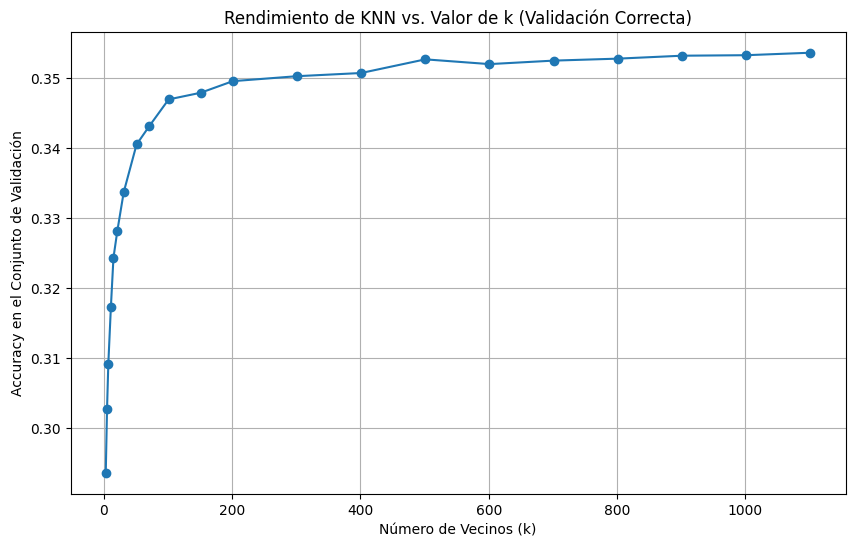

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

print(f"Shape de los datos completos: X_train={X_train.shape}, y_train={y_train.shape}")


print("\nDividiendo los datos en entrenamiento (80%) y validación (20%)...")
X_train_split, X_val, y_train_split, y_val = train_test_split(
    X_train, y_train, test_size=0.20, random_state=42, stratify=y_train
)

# CONSTRUIR EL ÍNDICE SOLO CON LOS DATOS DE ENTRENAMIENTO ---
print("\nConstruyendo índice Faiss usando ÚNICAMENTE el conjunto de entrenamiento (X_train_split)...")
faiss_index_eval = construir_indice_faiss(X_train_split)

k_values = [3, 5, 7, 11, 15, 21, 31, 51, 71, 101, 151, 201, 301, 401, 501, 601, 701, 801, 901, 1001, 1101]
accuracy_scores = []

print("\n--- Buscando el valor óptimo de k (Evaluación honesta) ---")
for k in k_values:

    y_pred_val = predecir_con_faiss(faiss_index_eval, y_train_split, X_val, k)
    
    # Calcular y guardar el accuracy
    score = accuracy_score(y_val, y_pred_val)
    accuracy_scores.append(score)
    print(f"  Accuracy para k={k}: {score:.4f}")

# Encontrar el mejor resultado
best_k_index = np.argmax(accuracy_scores)
best_k = k_values[best_k_index]
best_score = accuracy_scores[best_k_index]

print(f"\nMejor resultado REAL encontrado: k = {best_k} con un Accuracy de {best_score:.4f}")

# Visualizar los resultados
plt.figure(figsize=(10, 6))
plt.plot(k_values, accuracy_scores, marker='o', linestyle='-')
plt.title("Rendimiento de KNN vs. Valor de k (Validación Correcta)")
plt.xlabel("Número de Vecinos (k)")
plt.ylabel("Accuracy en el Conjunto de Validación")
plt.grid(True)
plt.show()
